# Semana 4 – Regularización en una Red Neuronal

## Objetivo
Comparar el desempeño de una red neuronal base (sin regularización) frente a una red neuronal con regularización mediante **Dropout**, con el fin de analizar su efecto sobre el **overfitting** y la **generalización**.

## Qué se va a evidenciar
- Entrenamiento de un modelo base
- Entrenamiento de un modelo con regularización
- Comparación de `loss` y `accuracy`
- Análisis breve del efecto de la regularización

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 7
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.19.0


## 1. Creación y preparación de los datos

Se utiliza un dataset sintético de clasificación binaria llamado `make_moons`, adecuado para observar el comportamiento del modelo con y sin regularización.

X_train: (240, 2)
X_test : (60, 2)


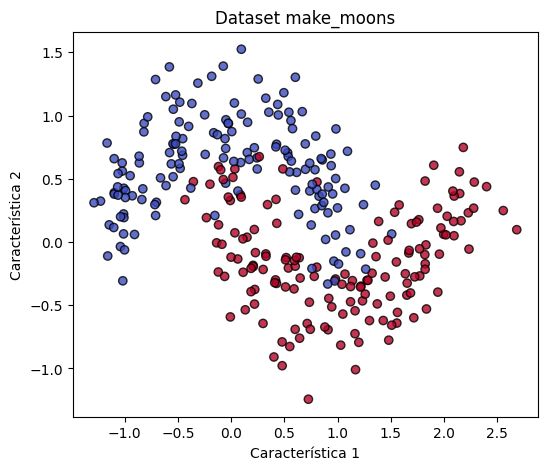

In [2]:
# Dataset sintético
X, y = make_moons(n_samples=300, noise=0.25, random_state=SEED)

# Separación entrenamiento / prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# Escalado
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print("X_train:", X_train_s.shape)
print("X_test :", X_test_s.shape)

# Visualización del dataset
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', edgecolor='k', alpha=0.8)
plt.title("Dataset make_moons")
plt.xlabel("Característica 1")
plt.ylabel("Característica 2")
plt.show()

## 2. Definición de modelos

Se construyen dos configuraciones:

1. **Modelo base:** sin regularización  
2. **Modelo con Dropout:** incorpora una capa de Dropout para reducir el sobreajuste

La arquitectura base se mantiene igual y solo cambia el componente de regularización.

In [3]:
INPUT_DIM = X_train_s.shape[1]
LR = 1e-3
EPOCHS = 60
BATCH = 32
VAL_SPLIT = 0.2

def compilar_modelo(modelo):
    modelo.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LR),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return modelo

def modelo_base():
    model = keras.Sequential([
        layers.Input(shape=(INPUT_DIM,)),
        layers.Dense(64, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ], name="Base")
    return compilar_modelo(model)

def modelo_dropout():
    model = keras.Sequential([
        layers.Input(shape=(INPUT_DIM,)),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid")
    ], name="Dropout")
    return compilar_modelo(model)

m1 = modelo_base()
m2 = modelo_dropout()

m1.summary()

Model: "Base"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 257 (1.00 KB)

 Trainable params: 257 (1.00 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Entrenamiento de los modelos

Ambos modelos se entrenan con el mismo dataset, misma cantidad de épocas, mismo optimizador y mismos parámetros.  
De esta forma, la comparación se centra únicamente en el efecto de la regularización.

In [4]:
h1 = m1.fit(
    X_train_s, y_train,
    validation_split=VAL_SPLIT,
    epochs=EPOCHS,
    batch_size=BATCH,
    verbose=0
)

h2 = m2.fit(
    X_train_s, y_train,
    validation_split=VAL_SPLIT,
    epochs=EPOCHS,
    batch_size=BATCH,
    verbose=0
)

print("Entrenamiento completado.")

Entrenamiento completado.


## 4. Evaluación y comparación

Se comparan las métricas principales en entrenamiento, validación y prueba para identificar señales de overfitting y cambios en la generalización.

In [5]:
def evaluar_modelo(modelo, historia, nombre):
    loss_test, acc_test = modelo.evaluate(X_test_s, y_test, verbose=0)

    train_loss_final = historia.history["loss"][-1]
    val_loss_final = historia.history["val_loss"][-1]
    best_val_loss = min(historia.history["val_loss"])
    best_val_acc = max(historia.history["val_accuracy"])

    gap = val_loss_final - train_loss_final

    return {
        "Modelo": nombre,
        "Train loss final": train_loss_final,
        "Val loss final": val_loss_final,
        "Best val loss": best_val_loss,
        "Best val acc": best_val_acc,
        "Test loss": loss_test,
        "Test accuracy": acc_test,
        "Gap (val_loss - train_loss)": gap
    }

resultados = [
    evaluar_modelo(m1, h1, "Base"),
    evaluar_modelo(m2, h2, "Dropout")
]

df = pd.DataFrame(resultados)
df

,Modelo,Train loss final,Val loss final,Best val loss,Best val acc,Test loss,Test accuracy,Gap (val_loss - train_loss)
0,Base,0.282470,0.341199,0.341199,0.875,0.506639,0.766667,0.058728
1,Dropout,0.279727,0.333860,0.333860,0.875,0.504200,0.783333,0.054133


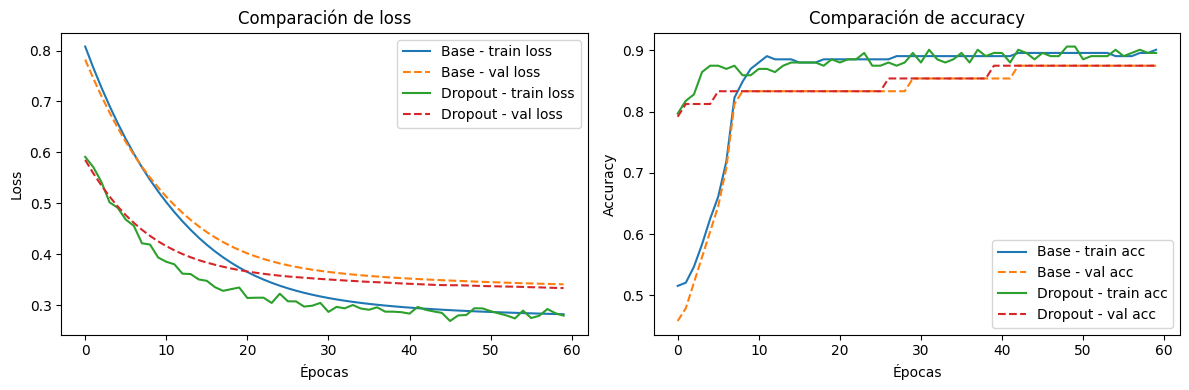

In [6]:
plt.figure(figsize=(12,4))

# Loss
plt.subplot(1,2,1)
plt.plot(h1.history["loss"], label="Base - train loss")
plt.plot(h1.history["val_loss"], label="Base - val loss", linestyle="--")
plt.plot(h2.history["loss"], label="Dropout - train loss")
plt.plot(h2.history["val_loss"], label="Dropout - val loss", linestyle="--")
plt.title("Comparación de loss")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(h1.history["accuracy"], label="Base - train acc")
plt.plot(h1.history["val_accuracy"], label="Base - val acc", linestyle="--")
plt.plot(h2.history["accuracy"], label="Dropout - train acc")
plt.plot(h2.history["val_accuracy"], label="Dropout - val acc", linestyle="--")
plt.title("Comparación de accuracy")
plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

## 5. Frontera de decisión

La frontera de decisión permite observar visualmente cómo clasifica cada modelo las dos clases y si la regularización genera una separación más estable o más suave.

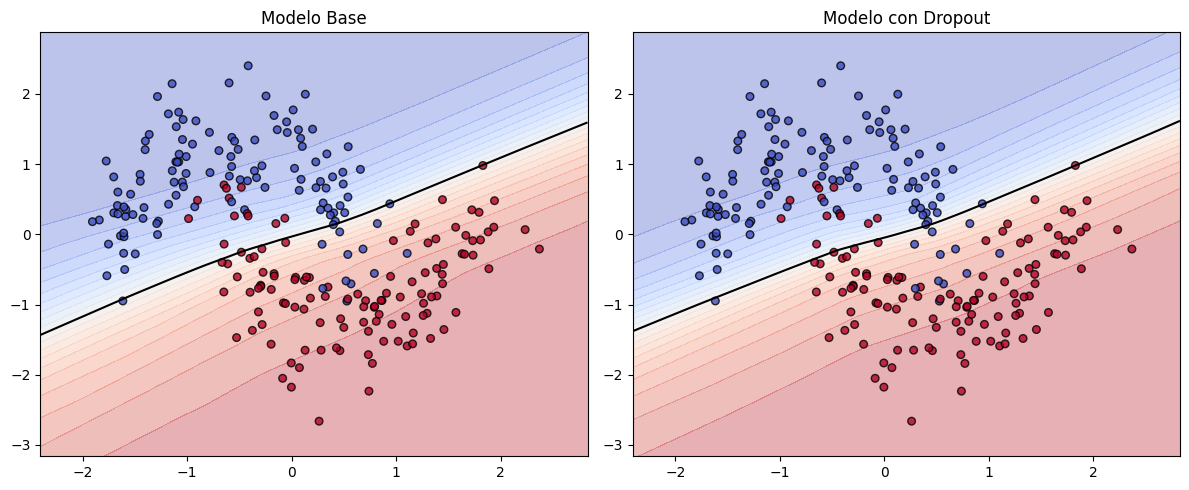

In [7]:
def dibujar_frontera(ax, modelo, titulo):
    h = 0.04
    x_min, x_max = X_train_s[:, 0].min() - 0.5, X_train_s[:, 0].max() + 0.5
    y_min, y_max = X_train_s[:, 1].min() - 0.5, X_train_s[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = modelo.predict(grid, verbose=0).reshape(xx.shape)

    ax.contourf(xx, yy, Z, levels=20, cmap="coolwarm", alpha=0.35)
    ax.contour(xx, yy, Z, levels=[0.5], colors="black", linewidths=1.5)

    ax.scatter(X_train_s[:,0], X_train_s[:,1], c=y_train, cmap="coolwarm", edgecolor="k", s=30, alpha=0.8)
    ax.set_title(titulo)

fig, axes = plt.subplots(1, 2, figsize=(12,5))
dibujar_frontera(axes[0], m1, "Modelo Base")
dibujar_frontera(axes[1], m2, "Modelo con Dropout")
plt.tight_layout()
plt.show()

## 6. Reporte del mejor modelo

Se identifica el modelo con mejor `accuracy` en test y se presenta su reporte de clasificación y matriz de confusión.

Mejor modelo: Dropout

              precision    recall  f1-score   support

           0       0.77      0.80      0.79        30
           1       0.79      0.77      0.78        30

    accuracy                           0.78        60
   macro avg       0.78      0.78      0.78        60
weighted avg       0.78      0.78      0.78        60



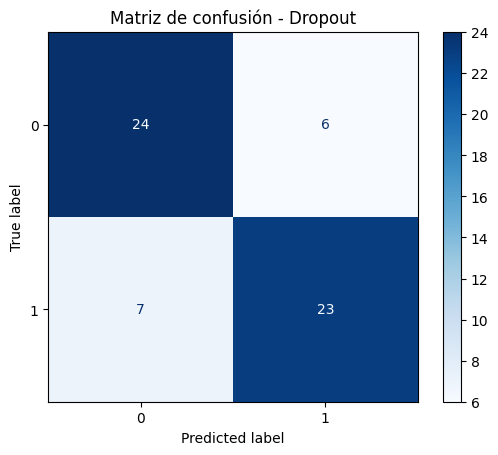

In [8]:
mejor_fila = df.sort_values("Test accuracy", ascending=False).iloc[0]
mejor_nombre = mejor_fila["Modelo"]

if mejor_nombre == "Base":
    mejor_modelo = m1
else:
    mejor_modelo = m2

y_pred = (mejor_modelo.predict(X_test_s, verbose=0) > 0.5).astype(int).ravel()

print("Mejor modelo:", mejor_nombre)
print()
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title(f"Matriz de confusión - {mejor_nombre}")
plt.show()

## 7. Conclusiones

- El modelo base y el modelo con Dropout fueron entrenados bajo las mismas condiciones, cambiando únicamente el componente de regularización.
- Si el modelo base presenta una mayor separación entre `train loss` y `val loss`, esto sugiere **overfitting**.
- El uso de **Dropout** puede ayudar a mejorar la generalización del modelo, al reducir la dependencia excesiva de ciertas neuronas durante el entrenamiento.
- En esta práctica, la regularización se evaluó mediante curvas de entrenamiento, métricas de validación y desempeño en test.
- Como hallazgo, la regularización no siempre aumenta mucho el accuracy, pero sí puede volver más estable el comportamiento del modelo frente a datos no vistos.